**Importing Dependencies**

In [16]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Data**

In [19]:
df = pd.read_csv('marketing_AB.csv')
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


**Removing irrelevant columns**

In [21]:
df.drop(columns=['Unnamed: 0','user id'],inplace=True)

df.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


**Dataset Overview**

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   test group     588101 non-null  object
 1   converted      588101 non-null  bool  
 2   total ads      588101 non-null  int64 
 3   most ads day   588101 non-null  object
 4   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(2), object(2)
memory usage: 18.5+ MB


In [27]:
df.describe()

,total ads,most ads hour
count,588101.000000,588101.000000
mean,24.820876,14.469061
std,43.715181,4.834634
min,1.000000,0.000000
25%,4.000000,11.000000
50%,13.000000,14.000000
75%,27.000000,18.000000
max,2065.000000,23.000000


In [29]:
## Unique Values

print("Test Group: ",df['test group'].unique())
print("Converted: ",df['converted'].unique())
print("Most ads day: ",df['most ads day'].unique())

Test Group:  ['ad' 'psa']
Converted:  [False  True]
Most ads day:  ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']


**Data Preprocessing**

In [33]:
## converted below to integer for numerical tests 
df['converted'] = df['converted'].astype(int)
df.dtypes

test group       object
converted         int64
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

**Intial Analysis**

Text(30.861728395061704, 0.5, 'Conversion Rate')

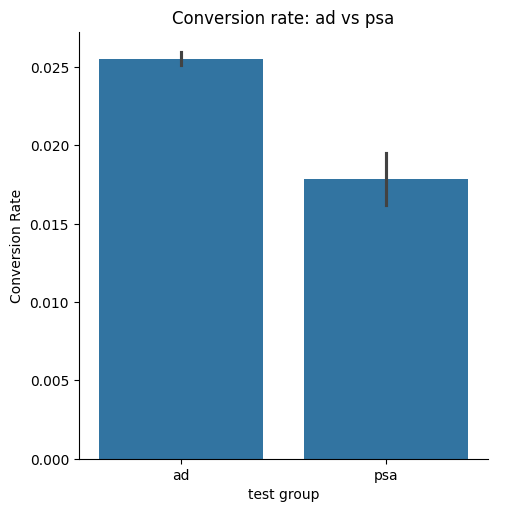

In [ ]:
## Difference in Converstion rate by Test Vs Control Groups
sns.catplot(data=df,x = 'test group',y = 'converted',kind='bar')
plt.title("Conversion rate: ad vs psa")
plt.ylabel("Conversion Rate")



Text(0.5, 1.0, 'Day wise Conversion rate')

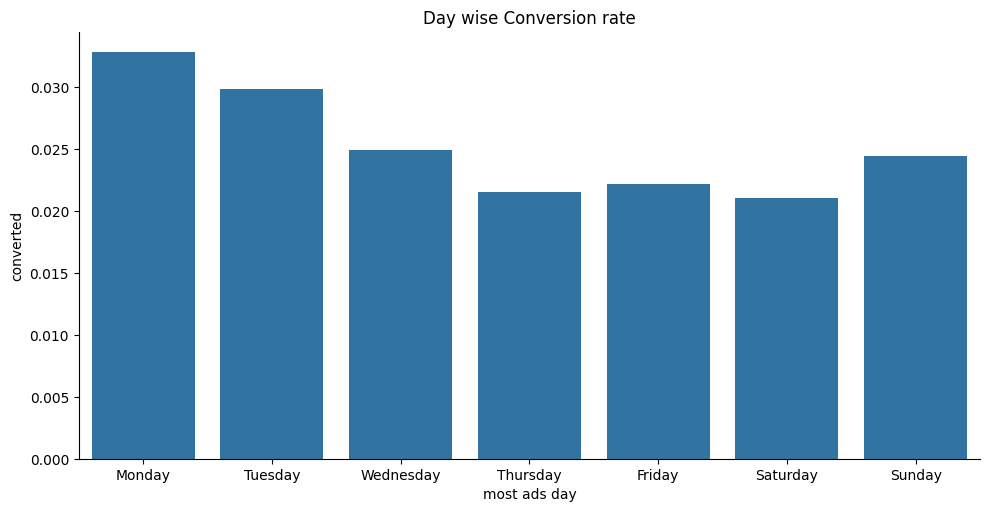

In [80]:
# Difference in Conversion : Day wise
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
days_conversion = df.groupby('most ads day')['converted'].mean()
sns.catplot(data=days_conversion,kind='bar',height=5,aspect=2,order=day_order)
plt.title('Day wise Conversion rate')

Text(0.5, 1.0, 'Hour Wise Conversion rate')

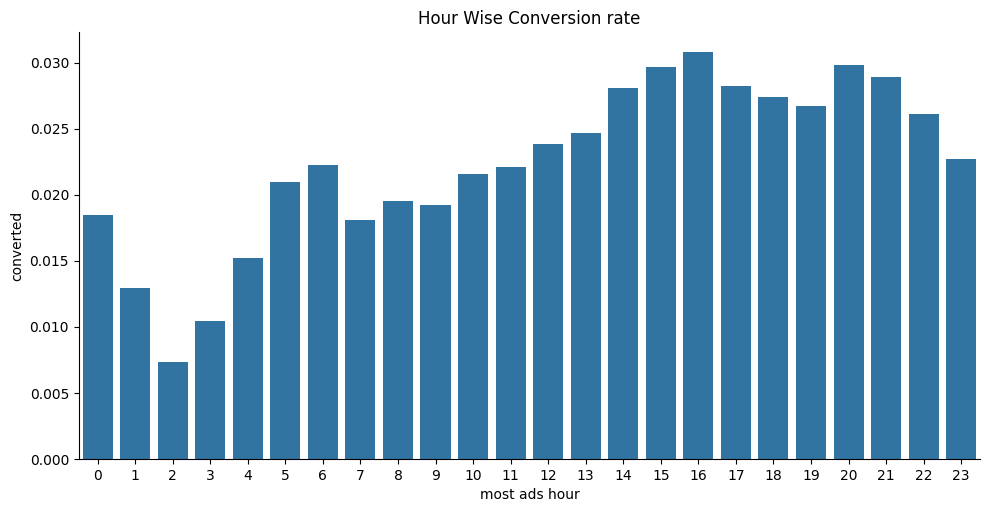

In [ ]:
# Difference in Conversion : Hour Wise
hourly_conversion = df.groupby('most ads hour')['converted'].mean()
sns.catplot(data=hourly_conversion,kind='bar',height=5,aspect=2)
plt.title('Hour Wise Conversion rate')

**A/B Test  - Comparing Converstion Rate using Independannt Two Sample T test**

In [62]:
control_group = df[df['test group']=='psa']
test_group = df[df['test group']=='ad']

control_conv = control_group['converted']
test_conv = test_group['converted']



t_stat,p_value = stats.ttest_ind(test_conv,control_conv)


if p_value<0.05:
    print("Significant Difference in Conversion Rate!: Reject Null Hypothesis")
else:
    print("No Significant Difference in Conversion Rate!: Failed to reject Null hypothesis")

Significant Difference in Conversion Rate!: Reject Null Hypothesis


**Effect Size of the difference in conversion rate due to ads and Should the Business Care ?**

In [77]:
test_conv_rate = test_conv.mean()
control_conv_rate = control_conv.mean()


lift = (test_conv_rate - control_conv_rate)/control_conv_rate*100
print(f"lift in conversion rate:{lift:.2f}%")

lift in conversion rate:43.09%


**Conclusion**

The advertisement treatment increased the conversion rate by approximately **43%** compared to the PSA control group. The independent t-test also indicates that this difference is statistically significant (p < 0.05), suggesting that the ad campaign had a meaningful positive impact on user conversions.